In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [25]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [26]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [27]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [29]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [30]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [31]:
X_test.head()

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0


In [32]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [33]:
X_train['Age_imputed']

30     40.0
10      4.0
873    47.0
182     9.0
876    20.0
       ... 
534    30.0
584     NaN
493    71.0
527     NaN
168     NaN
Name: Age_imputed, Length: 712, dtype: float64

In [34]:
[X_train['Age_imputed'].isnull()]

[30     False
 10     False
 873    False
 182    False
 876    False
        ...  
 534    False
 584     True
 493    False
 527     True
 168     True
 Name: Age_imputed, Length: 712, dtype: bool]

In [35]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [36]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([ 7.  , 39.  , 24.  , 38.  , 42.  , 16.  , 34.  , 25.  , 27.  ,
       29.  , 70.  , 25.  , 39.  , 28.  , 45.  , 25.  , 36.  , 21.  ,
       20.  , 33.  , 52.  , 16.  , 11.  , 19.  , 25.  , 38.  , 18.  ,
       27.  , 48.  , 38.  , 42.  , 32.  ,  4.  , 23.  , 30.  , 34.  ,
       31.  , 28.  , 58.  , 19.  , 34.  , 23.  , 21.  , 32.  , 28.5 ,
       25.  , 32.  , 21.  , 32.5 , 33.  , 27.  , 40.  , 30.  ,  1.  ,
       54.  , 24.  ,  0.75,  9.  , 40.  , 36.  , 39.  , 18.  , 30.  ,
       26.  , 24.  , 30.  , 36.  , 48.  , 22.  , 21.  , 25.  , 26.  ,
       28.  , 14.  , 35.  , 14.  , 28.  , 37.  , 18.  ,  9.  , 25.  ,
       38.  , 21.  , 28.  , 33.  , 18.  ,  8.  , 60.  , 53.  , 52.  ,
       24.  , 27.  , 35.  , 24.  , 40.  , 30.  , 30.  , 61.  , 34.  ,
       23.  , 18.  , 34.  , 45.  , 31.  , 24.  , 54.  , 28.  , 11.  ,
       30.  , 40.  , 33.  ,  2.  , 70.5 ,  1.  , 29.  , 28.5 , 26.  ,
       30.  , 24.  , 35.  , 65.  , 31.  , 29.  , 32.  , 35.  , 23.  ,
       15.  , 28.  ,

In [37]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [39]:
X_train['Age'].isnull().sum()

np.int64(148)

In [40]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,30.0
493,71.0,49.5042,71.0
527,NaN,221.7792,39.0


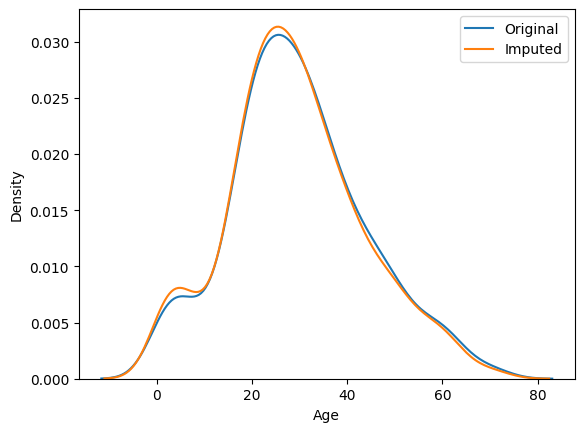

In [50]:
sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [51]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  200.99457974347732


In [43]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,51.580612
Age,71.512440,204.349513,204.349513
Age_imputed,51.580612,204.349513,200.994580


<Axes: >

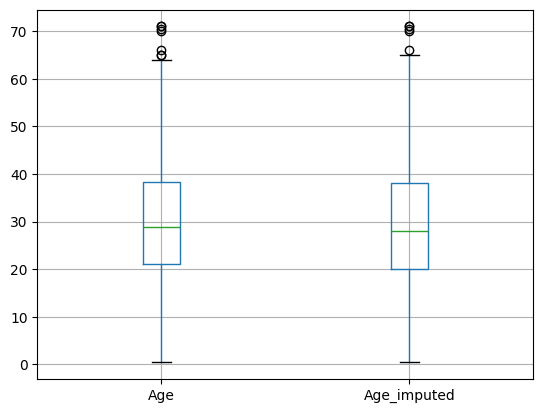

In [44]:
X_train[['Age', 'Age_imputed']].boxplot()

In [52]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

#### Categorical Data

In [54]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [55]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [56]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [57]:
X = data
y = data['SalePrice']

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [59]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [60]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
841,Po,Gd,157500,Gd,Po
153,Gd,TA,235000,TA,Gd
1057,Gd,TA,248000,TA,Gd
63,NaN,TA,140000,TA,NaN
607,NaN,TA,225000,TA,NaN


In [ ]:
# same technique that was used in Regression
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [62]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [ ]:
# no issue the distribution is almost same
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.035959
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [69]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']


In [ ]:
# big issue in the "FireplaceQu" column (Don't apply RandomImputation on this column)
temp

,original,imputed
Gd,0.494272,0.649832
TA,0.412439,0.537598
Fa,0.040917,0.053872
Po,0.027823,0.037037
Ex,0.024550,0.032548


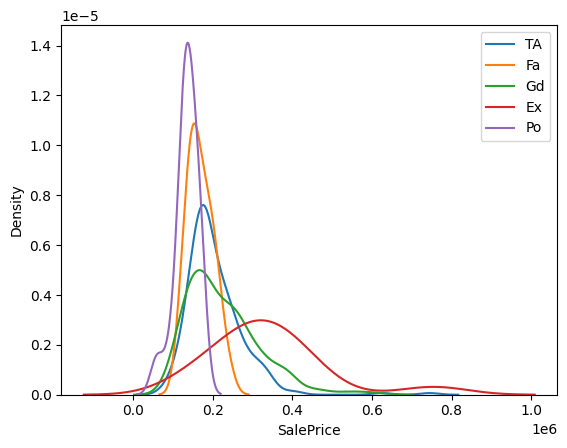

In [68]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label = category)
    plt.legend()
plt.show()

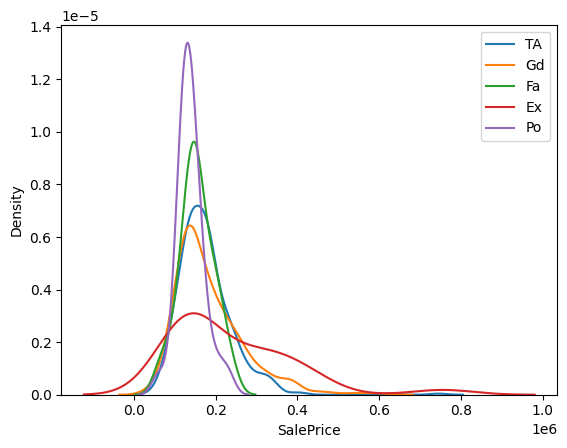

In [ ]:
# see the kdeplot is changing much more 
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label = category)
    plt.legend()
plt.show()